<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">
  <strong>ANALYSIS OF COMMODITY PRICES ACROSS INDIAN MARKETS</strong>
</h1>



## Introduction

Agricultural markets play an important role in the Indian economy, and the prices of commodities vary widely across different regions, markets and time periods due to changes in supply, demand and local market conditions. Analysing these price variations is essential for understanding market behaviour and supporting better planning and decision-making for farmers, traders and policy makers.

This project focuses on the exploratory analysis of commodity price data collected from various markets across India. Using Python and data analysis techniques, the study examines price patterns across states, districts and commodities, and explores the relationships between minimum, maximum and modal prices. Through data cleaning, exploratory data analysis and visualisation, the project aims to identify meaningful trends, regional differences and important insights that can help in understanding the overall behaviour of commodity prices in Indian markets.

## Data Source

The dataset used in this analysis is sourced from the Government of India’s open data platform https://www.data.gov.in/, specifically from the “Variety-wise Daily Market Prices Data – Commodity” resource. This publicly available dataset contains daily market price information for various commodities across multiple markets in India.

Source link:
https://www.data.gov.in/resource/variety-wise-daily-market-prices-data-commodity

## Attribute Details

| Attribute Name | Description                                                  |
| -------------- | ------------------------------------------------------------ |
| State          | Name of the state where the market is located                |
| District       | Name of the district of the market                           |
| Market         | Name of the agricultural market                              |
| Commodity      | Name of the commodity                                        |
| Variety        | Variety of the commodity                                     |
| Grade          | Quality grade of the commodity                               |
| Arrival_Date   | Date on which the commodity arrived at the market            |
| Min_Price      | Minimum price of the commodity on that day                   |
| Max_Price      | Maximum price of the commodity on that day                   |
| Modal_Price    | Most frequently occurring price of the commodity on that day |
| Commodity_Code | Unique code assigned to each commodity                       |


## Imported the Required Libraries

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


NB: Import the required libraries to handle data, perform analysis, and create clear visualizations for our commodity market project.

pandas – to load the dataset, clean data, create new features, and perform group-by and pivot analysis.

numpy – to support numerical operations used during calculations and feature engineering.

matplotlib – to create basic and fully controlled charts (bar, line, histogram, box, etc.).

seaborn – to generate statistical and relationship-based plots such as heatmaps, boxplots, and pair plots.

plotly – to build interactive visualizations for better exploration of prices, markets, and commodities.

<div style="background-color:#e3f2fd; padding:15px; border-radius:10px;">
  <h1 style="color:#0d47a1; text-align:center;">
    <strong>1. Data Loading and the Initial Overview </strong>
  </h1>
</div>


 ### 1.1 Imported Librarires 

In [172]:
import pandas as pd
import numpy as np

### 1.2 Dataset Loading

In [173]:
df = pd.read_csv("Price of various commodities from various markets.csv")


 ### 1.3 Dataset Overview

In [174]:
print("Number of Rows:",df.shape[0]) #Showing number of rows and columns
print("Number of Columns:", df.shape[1])


Number of Rows: 7000
Number of Columns: 11


In [175]:
df.head() # to show first 5 Rows of the Dataset

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Madhya Pradesh,Alirajpur,Alirajpur APMC,Wheat,Wheat,FAQ,01-01-2026,2400.0,2400.0,2400.0,1
1,Madhya Pradesh,Ratlam,Sailana APMC,Wheat,Wheat,FAQ,01-01-2026,2340.0,3201.0,3201.0,1
2,Madhya Pradesh,Gwalior,Dabra APMC,Wheat,Wheat,FAQ,01-01-2026,2450.0,2500.0,2500.0,1
3,Madhya Pradesh,Damoh,Patharia APMC,Wheat,Wheat,FAQ,01-01-2026,2500.0,2500.0,2500.0,1
4,Madhya Pradesh,Khandwa,Pandhana APMC,Wheat,Wheat,FAQ,01-01-2026,2550.0,2550.0,2550.0,1


In [176]:
df.info() # to Check column names & data types

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           7000 non-null   str    
 1   District        7000 non-null   str    
 2   Market          7000 non-null   str    
 3   Commodity       7000 non-null   str    
 4   Variety         7000 non-null   str    
 5   Grade           7000 non-null   str    
 6   Arrival_Date    7000 non-null   str    
 7   Min_Price       7000 non-null   float64
 8   Max_Price       7000 non-null   float64
 9   Modal_Price     7000 non-null   float64
 10  Commodity_Code  7000 non-null   int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 601.7 KB


In [177]:
df.describe() #to check Statistical summary.

,Min_Price,Max_Price,Modal_Price,Commodity_Code
count,7000.000000,7000.000000,7000.000000,7000.000000
mean,4201.017114,4910.611815,4575.975931,144.097429
std,5690.173936,6806.935121,6270.190380,103.558422
min,1.000000,1.000000,1.000000,1.000000
25%,2000.000000,2369.000000,2150.000000,78.000000
50%,3200.000000,4000.000000,3500.000000,154.000000
75%,5000.000000,5800.000000,5400.000000,172.000000
max,160000.000000,180000.000000,160000.000000,443.000000


<div style="background-color:#e3f2fd; padding:15px; border-radius:10px;">
  <h1 style="color:#0d47a1; text-align:center;">
    
  <strong> 2. Data Pre-processing </strong></h1>
</div>

### 2.1 Finding the Missing Value count

In [178]:
missing_values_per_column = df.isnull().sum() #Missing values per column
print("Missing values per column:")
display(missing_values_per_column)
total_missing_values = df.isnull().sum().sum()
print(f"\nTotal number of missing values in the dataset: {total_missing_values}")

Missing values per column:


State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64


Total number of missing values in the dataset: 0


 NB:There are no missing values in the dataset.

### 2.2 Identifying and Removing Duplicate Records

In [179]:
df.duplicated().sum()


np.int64(0)

 NB:There are no duplicate records in the dataset.

### 2.3 Fix Date column

Fix Arrival_Date column -Right now it is text, converting it to real date.

In [180]:
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'], format='%d-%m-%Y')#Fixing Arrival_Date column

### 2.4 Derived columns

In [181]:
df['Year'] = df['Arrival_Date'].dt.year #Creating new column
df['Month'] = df['Arrival_Date'].dt.month#Creating new column

### 2.5 Data Validation


In [182]:
# This checks if any record has wrong pricing order.
(df['Min_Price'] > df['Max_Price']).sum() 

np.int64(0)

### 2.6 Standardizing Column Names


In [183]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [184]:
df.head()

,state,district,market,commodity,variety,grade,arrival_date,min_price,max_price,modal_price,commodity_code,year,month
0,Madhya Pradesh,Alirajpur,Alirajpur APMC,Wheat,Wheat,FAQ,2026-01-01,2400.0,2400.0,2400.0,1,2026,1
1,Madhya Pradesh,Ratlam,Sailana APMC,Wheat,Wheat,FAQ,2026-01-01,2340.0,3201.0,3201.0,1,2026,1
2,Madhya Pradesh,Gwalior,Dabra APMC,Wheat,Wheat,FAQ,2026-01-01,2450.0,2500.0,2500.0,1,2026,1
3,Madhya Pradesh,Damoh,Patharia APMC,Wheat,Wheat,FAQ,2026-01-01,2500.0,2500.0,2500.0,1,2026,1
4,Madhya Pradesh,Khandwa,Pandhana APMC,Wheat,Wheat,FAQ,2026-01-01,2550.0,2550.0,2550.0,1,2026,1


### 2.7  Feature Engineering 





Although the dataset is already clean and does not contain missing values or duplicate records. Therefore, instead of focusing on data cleaning, a feature engineering step was introduced to enhance the analytical value of the dataset. New derived attributes such as 'region' (based on state) and 'commodity_type' (based on commodity type) were created to enable higher-level, meaningful and comparative analysis. This helps in identifying regional price patterns and category-wise trends, improves interpretability of results, and supports more insightful visualizations and decision-making.

#### Section 1

A new derived feature named 'region' was created using conditional logic (if–elif statements) by grouping Indian states into major     geographical regions such as South, North, Central, West, East and North-East. This feature enables region-wise analysis of commodity prices.

In [185]:
df['state'].unique() #shows which state names are present.

<StringArray>
[   'Madhya Pradesh',            'Punjab',            'Kerala',
  'Himachal Pradesh',           'Haryana',       'West Bengal',
         'Rajasthan',         'Telangana',           'Gujarat',
       'Maharashtra',         'Karnataka',        'Tamil Nadu',
     'Uttar Pradesh',             'Assam',            'Odisha',
      'NCT of Delhi',           'Tripura',       'Uttarakhand',
 'Jammu and Kashmir',    'Andhra Pradesh',        'Chandigarh',
             'Bihar',       'Chattisgarh',           'Manipur',
               'Goa',         'Meghalaya']
Length: 26, dtype: str

Creating 'region' using IF condition

In [186]:
def assign_region(state):

    # South India
    if state in ["Tamil Nadu", "Kerala", "Karnataka", "Andhra Pradesh", "Telangana"]:
        return "South"

    # North India
    elif state in ["NCT of Delhi", "Punjab", "Haryana", "Uttar Pradesh",
                   "Uttarakhand", "Himachal Pradesh",
                   "Jammu and Kashmir","Chandigarh"]:
        return "North"

    # Central India
    elif state in ["Madhya Pradesh", "Chattisgarh"]:
        return "Central"

    # West India
    elif state in ["Maharashtra", "Gujarat", "Rajasthan", "Goa"]:
        return "West"

    # East India
    elif state in ["West Bengal", "Odisha", "Bihar"]:
        return "East"

    # North East India
    elif state in ["Assam", "Meghalaya", "Manipur","Tripura"]:
        return "North East"

    else:
        return "Other"


In [187]:
df['region'] = df['state'].apply(assign_region) #Applying this IF logic to dataset

In [188]:
df[['state', 'region']].head() #Checking new column


,state,region
0,Madhya Pradesh,Central
1,Madhya Pradesh,Central
2,Madhya Pradesh,Central
3,Madhya Pradesh,Central
4,Madhya Pradesh,Central


In [189]:
df[df['region'] == "Other"]['state'].unique()# Checking if anything went into "Other"

<StringArray>
[]
Length: 0, dtype: str

#### Section 2

A new feature named 'commodity_type' was created using conditional logic (if-elif statements) to classify individual commodities into broader categories such as Vegetables, Fruits, Pulses, Cereals/Millets, Spices, Oilseeds, Flowers and Livestock/Animal. This feature enables category-wise price analysis and improves interpretability of the results.


In [190]:
df['commodity'].unique() #shows which commodity names are present.


<StringArray>
[                             'Wheat',                            'Cabbage',
                      'Suvarna Gadde',                              'Ajwan',
                       'Betal Leaves', 'Elephant Yam(Suran)/Amorphophallus',
             'Pegeon Pea(Arhar Fali)',                 'Indian Beans(Seam)',
                'Surat Beans(Papadi)',                            'Brinjal',
 ...
                        'Cauliflower',                       'Black pepper',
                'Ragi(Finger Millet)',                     'Jowar(Sorghum)',
                        'Barley(Jau)',                             'Coffee',
                          'Safflower',                           'Red Gram',
                              'Apple',                              'Soanf']
Length: 183, dtype: str

NB: 183 different commodity names in the dataset.

In [191]:
for c in sorted(df['commodity'].unique()): #to see the FULL list clearly
    print(c)


Ajwan
Alasande Gram
Amla(Nelli Kai)
Apple
Arecanut(Betelnut/Supari)
Arhar Dal(Tur Dal)
Arhar(Tur/Red Gram)(Whole)
Ashgourd
Ashwagandha
Astera
Bajra(Pearl Millet/Cumbu)
Banana
Barley(Jau)
Beetroot
Bengal Gram Dal(Chana Dal)
Bengal Gram(Gram)(Whole)
Ber(Zizyphus/Borehannu)
Betal Leaves
Bhindi(Ladies Finger)
Bitter gourd
Black Gram Dal(Urd Dal)
Black Gram(Urd Beans)(Whole)
Black pepper
Bottle gourd
Brinjal
Bunch Beans
Cabbage
Capsicum
Carrot
Cauliflower
Chapparad Avare
Chikoos(Sapota)
Chili Red
Chow Chow
Chrysanthemum(Loose)
Cluster beans
Cock
Coconut
Coconut Oil
Coffee
Colacasia
Corriander seed
Cotton
Cowpea(Veg)
Cucumbar(Kheera)
Custard Apple(Sharifa)
Delha
Drumstick
Dry Chillies
Dry Fodder
Dry Grapes
Duster Beans
Elephant Yam(Suran)/Amorphophallus
Field Pea
Fig(Anjura/Anjeer)
Firewood
Fish
French Beans(Frasbean)
Garlic
Ghee
Ginger(Dry)
Ginger(Green)
Goat
Grapes
Green Avare(W)
Green Chilli
Green Fodder
Green Gram Dal(Moong Dal)
Ground Nut Seed
Groundnut
Groundnut(Split)
Guar
Guar Seed(C

Creating 'commodity type' using IF condition

In [192]:
def assign_commodity_type(commodity):

    # -------------------------------
    # Vegetables
    # -------------------------------
    if commodity in [
        "Ashgourd","Beetroot","Bhindi(Ladies Finger)","Bitter gourd","Bottle gourd",
        "Brinjal","Bunch Beans","Cabbage","Capsicum","Carrot","Cauliflower",
        "Chow Chow","Cluster beans","Colacasia","Cowpea(Veg)","Cucumbar(Kheera)",
        "Drumstick","Elephant Yam(Suran)/Amorphophallus","French Beans(Frasbean)",
        "Green Avare(W)","Green Chilli","Indian Beans(Seam)","Knool Khol",
        "Ladies Finger","Leafy Vegetable","Little gourd(Kundru)","Long Melon(Kakri)",
        "Mint(Pudina)","Onion","Onion Green","Peas Wet","Peas cod",
        "Pegeon Pea(Arhar Fali)","Pointed gourd(Parval)","Potato","Pumpkin",
        "Raddish","Ridgeguard(Tori)","Round gourd","Season Leaves","Snakeguard",
        "Spinach","Sponge gourd","Squash(Chappal Kadoo)","Suvarna Gadde",
        "Sweet Potato","Sweet Pumpkin","Tapioca","Thogrikai","Tinda","Tomato",
        "Turnip","White Pumpkin","Yam(Ratalu)"
    ]:
        return "Vegetable"

    # -------------------------------
    # Fruits
    # -------------------------------
    elif commodity in [
        "Amla(Nelli Kai)","Apple","Banana","Ber(Zizyphus/Borehannu)","Chikoos(Sapota)",
        "Custard Apple(Sharifa)","Dry Grapes","Fig(Anjura/Anjeer)","Grapes","Guava",
        "Jack Fruit","Karbuja(Musk Melon)","Kinnow","Lemon","Lime","Mango",
        "Mango(Raw-Ripe)","Mousambi(Sweet Lime)","Orange","Papaya","Papaya(Raw)",
        "Pear(Marasebu)","Persimon(Japani Fal)","Pineapple","Plum","Pomegranate",
        "Seetapal","Tender Coconut"
    ]:
        return "Fruit"

    # -------------------------------
    # Pulses
    # -------------------------------
    elif commodity in [
        "Alasande Gram","Arhar Dal(Tur Dal)","Arhar(Tur/Red Gram)(Whole)",
        "Bengal Gram Dal(Chana Dal)","Bengal Gram(Gram)(Whole)",
        "Black Gram Dal(Urd Dal)","Black Gram(Urd Beans)(Whole)",
        "Field Pea","Green Gram Dal(Moong Dal)","Kabuli Chana(Chickpeas-White)",
        "Kulthi(Horse Gram)","Lentil(Masur)(Whole)","Masur Dal","Peas(Dry)",
        "Rajgir","Red Gram","White Peas"
    ]:
        return "Pulse"

    # -------------------------------
    # Cereals / Millets
    # -------------------------------
    elif commodity in [
        "Bajra(Pearl Millet/Cumbu)","Barley(Jau)","Jowar(Sorghum)",
        "Maida Atta","Maize","Millets","Paddy(Basmati)","Paddy(Common)",
        "Ragi(Finger Millet)","Rice","Wheat"
    ]:
        return "Cereal / Millet"

    # -------------------------------
    # Spices
    # -------------------------------
    elif commodity in [
        "Ajwan","Black pepper","Chili Red","Corriander seed","Garlic",
        "Ginger(Dry)","Ginger(Green)","Mace","Pepper ungarbled","Soanf",
        "Suva(Dill Seed)","Turmeric(raw)","nigella","poppy seeds"
    ]:
        return "Spice"

    # -------------------------------
    # Oilseeds
    # -------------------------------
    elif commodity in [
        "Ground Nut Seed","Groundnut","Groundnut(Split)",
        "Indian Colza(Sarson)","Mustard","Sesamum(Sesame,Gingelly,Til)",
        "Soyabean","Safflower"
    ]:
        return "Oilseed"

    # -------------------------------
    # Flowers
    # -------------------------------
    elif commodity in [
        "Chrysanthemum(Loose)","Jasmine","Lilly","Marigold(Calcutta)",
        "Marigold(loose)","Rose(Local)","Rose(Loose))",
        "Tube Flower","Tube Rose(Loose)"
    ]:
        return "Flower"

    # -------------------------------
    # Livestock / Animal products
    # -------------------------------
    elif commodity in [
        "Cock","Fish","Goat","He Buffalo","She Buffalo","Sheep",
        "Ghee"
    ]:
        return "Livestock / Animal"

    else:
        return "Other"


In [193]:
df['commodity_type'] = df['commodity'].apply(assign_commodity_type) #Creating the new column

In [194]:
df[['commodity','commodity_type']].head() #Checking new column

,commodity,commodity_type
0,Wheat,Cereal / Millet
1,Wheat,Cereal / Millet
2,Wheat,Cereal / Millet
3,Wheat,Cereal / Millet
4,Wheat,Cereal / Millet


In [195]:
df['commodity_type'].value_counts() #See how many items fall into each type

commodity_type
Vegetable             4748
Fruit                  909
Cereal / Millet        390
Other                  322
Oilseed                204
Spice                  187
Pulse                  176
Flower                  45
Livestock / Animal      19
Name: count, dtype: int64

In [196]:
df[df['commodity_type']=="Other"]['commodity'].unique() #Check what went into 'other'.

<StringArray>
[                 'Betal Leaves',           'Surat Beans(Papadi)',
                       'Coconut',                   'Mustard Oil',
                'Tamarind Fruit',                   'Coconut Oil',
                          'Wood',                         'Mahua',
             'Isabgul(Psyllium)',                  'Green Fodder',
                    'Dry Fodder',                     'Mashrooms',
 'Guar Seed(Cluster Beans Seed)',                       'buttery',
                         'Kutki',                        'Kakada',
                   'Ashwagandha',                      'Firewood',
                  'Dry Chillies',     'Arecanut(Betelnut/Supari)',
               'Chapparad Avare',                  'Duster Beans',
                     'Sugarcane',                 'Seemebadnekai',
                  'Gur(Jaggery)',                        'Rubber',
                        'Marget',                        'Raibel',
                          'Guar',               

NB: 35 commodity names went into 'other'

### **2.8 Final Dataset Overview**

In [197]:
print("Number of Rows:",df.shape[0]) # Showing number of raws and columns
print("Number of Columns:", df.shape[1])


Number of Rows: 7000
Number of Columns: 15


In [198]:
df.head()# to show first 5 Rows of the Dataset

,state,district,market,commodity,variety,grade,arrival_date,min_price,max_price,modal_price,commodity_code,year,month,region,commodity_type
0,Madhya Pradesh,Alirajpur,Alirajpur APMC,Wheat,Wheat,FAQ,2026-01-01,2400.0,2400.0,2400.0,1,2026,1,Central,Cereal / Millet
1,Madhya Pradesh,Ratlam,Sailana APMC,Wheat,Wheat,FAQ,2026-01-01,2340.0,3201.0,3201.0,1,2026,1,Central,Cereal / Millet
2,Madhya Pradesh,Gwalior,Dabra APMC,Wheat,Wheat,FAQ,2026-01-01,2450.0,2500.0,2500.0,1,2026,1,Central,Cereal / Millet
3,Madhya Pradesh,Damoh,Patharia APMC,Wheat,Wheat,FAQ,2026-01-01,2500.0,2500.0,2500.0,1,2026,1,Central,Cereal / Millet
4,Madhya Pradesh,Khandwa,Pandhana APMC,Wheat,Wheat,FAQ,2026-01-01,2550.0,2550.0,2550.0,1,2026,1,Central,Cereal / Millet


In [199]:
df.info()# to Check column names & data types

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   state           7000 non-null   str           
 1   district        7000 non-null   str           
 2   market          7000 non-null   str           
 3   commodity       7000 non-null   str           
 4   variety         7000 non-null   str           
 5   grade           7000 non-null   str           
 6   arrival_date    7000 non-null   datetime64[us]
 7   min_price       7000 non-null   float64       
 8   max_price       7000 non-null   float64       
 9   modal_price     7000 non-null   float64       
 10  commodity_code  7000 non-null   int64         
 11  year            7000 non-null   int32         
 12  month           7000 non-null   int32         
 13  region          7000 non-null   str           
 14  commodity_type  7000 non-null   str           
dtypes: datetime64[u

NB:After completing the feature engineering process, the dataset was reviewed to confirm its updated structure. The final dataset contains 7,000 rows and 15 columns, indicating that the newly created features were successfully added without altering the original records. This verification ensures that the dataset is ready for further exploratory data analysis and visualisation.

<div style="background-color:#e3f2fd; padding:15px; border-radius:10px;">
  <h1 style="color:#0d47a1; text-align:center;">
    <strong>3. Exploratory Data Analysis (EDA) and Visualization</strong>
  </h1>
</div>

## **3.1 Descriptive Statistics**

### 3.1.1 Overall summary of numerical columns

In [200]:
df.describe() #Overall summary of numerical columns

,arrival_date,min_price,max_price,modal_price,commodity_code,year,month
count,7000,7000.000000,7000.000000,7000.000000,7000.000000,7000.0,7000.0
mean,2026-01-04 00:00:00,4201.017114,4910.611815,4575.975931,144.097429,2026.0,1.0
min,2026-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,2026.0,1.0
25%,2026-01-02 00:00:00,2000.000000,2369.000000,2150.000000,78.000000,2026.0,1.0
50%,2026-01-04 00:00:00,3200.000000,4000.000000,3500.000000,154.000000,2026.0,1.0
75%,2026-01-06 00:00:00,5000.000000,5800.000000,5400.000000,172.000000,2026.0,1.0
max,2026-01-07 00:00:00,160000.000000,180000.000000,160000.000000,443.000000,2026.0,1.0
std,NaN,5690.173936,6806.935121,6270.190380,103.558422,0.0,0.0


INSIGHTS

The numerical summary shows that the dataset contains wide price variation and meaningful differences across markets and commodities, making it suitable for market comparison and price trend analysis.

### 3.1.2 Mean, min and max price by Region

In [201]:
df.groupby('region')['modal_price'] \
  .agg(['mean','min','max'])

,mean,min,max
region,,,
Central,4631.498688,150.0,136500.0
East,3829.003509,600.0,22500.0
North,3033.132226,220.0,160000.0
North East,4511.370976,2.5,30000.0
South,5411.911101,120.0,160000.0
West,4036.555622,1.0,72500.0


INSIGHTS

The South region has the highest average modal price (₹5,411.91), while the North region has the lowest average price (₹3,033.13).
Very low minimum prices and very high maximum prices across all regions indicate a wide range of price variation in the dataset.

### 3.1.3 Mean, min and max price by Commodity type

In [202]:
df.groupby('commodity_type')['modal_price'] \
  .agg(['mean','min','max'])


,mean,min,max
commodity_type,,,
Cereal / Millet,2642.887179,1380.0,7000.0
Flower,22356.666667,300.0,160000.0
Fruit,5959.924422,1.0,38000.0
Livestock / Animal,23757.894837,4000.0,55000.0
Oilseed,5562.539216,1250.0,12500.0
Other,10609.284161,15.0,160000.0
Pulse,7319.255682,300.0,15500.0
Spice,12896.219251,1400.0,136500.0
Vegetable,3343.587766,3.0,36000.0


INSIGHTS

Livestock/Animal and Flower commodities have the highest average prices, while Cereals/Millets and Vegetables have the lowest average prices.
The large gap between minimum and maximum prices for several commodity types indicates high price variability across different commodities and markets.

# **3.2 Univariate, Bivariate and Multivariate Analysis**

### 3.2.1 Count of records by Region-Univariate Analysis

In [203]:
df['region'].value_counts()


region
South         3735
North         1626
West           756
Central        381
East           285
North East     217
Name: count, dtype: int64

INSIGHTS

The South region has the highest number of records (3,735), followed by North (1,626) and West (756). Central (381), East (285) and North-East (217) have comparatively fewer records, indicating uneven regional market data coverage.

### 3.2.2 Count of records by Commodity Type-Univariate Analysis

In [204]:
df['commodity_type'].value_counts()


commodity_type
Vegetable             4748
Fruit                  909
Cereal / Millet        390
Other                  322
Oilseed                204
Spice                  187
Pulse                  176
Flower                  45
Livestock / Animal      19
Name: count, dtype: int64

INSIGHTS

Vegetables dominate the dataset with 4,748 records, followed by Fruits (909) and Cereals/Millets (390). Other categories such as Oilseeds (204), Spices (187), Pulses (176), Flowers (45) and Livestock/Animal (19) have comparatively fewer records, showing that the data is mainly concentrated on vegetable and fruit commodities.

### 3.2.3 Average price by Region using Groupby-Bivariate Analysis

In [205]:
region_price = (
    df.groupby('region')['modal_price']
      .mean()
      .reset_index()
)

region_price


,region,modal_price
0,Central,4631.498688
1,East,3829.003509
2,North,3033.132226
3,North East,4511.370976
4,South,5411.911101
5,West,4036.555622


INSIGHTS

The South region records the highest average modal price (₹5,411.91), followed by Central (₹4,631.50) and North-East (₹4,511.37). East (₹3,829.00), West (₹4,036.56) and North (₹3,033.13) show comparatively lower average prices, indicating clear regional variation in commodity prices.

### 3.2.4 Average price by Commodity type using Groupby-Bivariate Analysis

In [206]:
group_price = (
    df.groupby('commodity_type')['modal_price']
      .mean()
      .reset_index()
)

group_price


,commodity_type,modal_price
0,Cereal / Millet,2642.887179
1,Flower,22356.666667
2,Fruit,5959.924422
3,Livestock / Animal,23757.894837
4,Oilseed,5562.539216
5,Other,10609.284161
6,Pulse,7319.255682
7,Spice,12896.219251
8,Vegetable,3343.587766


INSIGHTS

Livestock/Animal commodities have the highest average price (₹23,757.89 per quintal), followed by Flowers (₹22,356.67) and Spices (₹12,896.22). Pulses (₹7,319.26) and Fruits (₹5,959.92) show moderate average prices, while Vegetables (₹3,343.59) and Cereals/Millets (₹2,642.89) record comparatively lower average prices.

### 3.2.5 Pivot Table Analysis-Region vs Commodity type

In [207]:
pivot_table=pd.pivot_table(
    df,
    values='modal_price',
    index='region',
    columns='commodity_type',
    aggfunc='mean'
)

pivot_table


commodity_type,Cereal / Millet,Flower,Fruit,Livestock / Animal,Oilseed,Other,Pulse,Spice,Vegetable
region,,,,,,,,,
Central,2600.519774,NaN,NaN,NaN,5054.078431,5811.476190,6062.320755,32710.700000,1019.000000
East,3024.500000,12000.00,5114.285714,10000.000000,6275.000000,11488.000000,10186.785714,6975.000000,3153.626609
North,2675.567568,8100.00,5195.942966,32300.000000,5920.555556,13371.444444,7575.744681,8246.125000,1653.344377
North East,3834.375000,NaN,5658.750000,17442.857414,NaN,19000.000000,11964.285714,12300.000000,3195.730337
South,2386.717391,24118.75,6561.802174,19100.000000,7027.000000,11349.416244,6154.800000,14445.617978,4220.836062
West,2582.572222,5000.00,4434.209877,45000.000000,5914.153846,8072.604839,6293.763158,9858.073171,2211.219918


INSIGHTS

The pivot table shows that average prices for the same commodity type vary across regions, indicating a combined influence of region and commodity category on prices.
Higher average prices are observed for Livestock/Animal, Flowers and Spices in several regions, while Vegetables and Cereals/Millets remain consistently lower across most regions.

### 3.2.6 Region + Commodity type + price- Multivariate Table Analysis

In [208]:
multi_analysis = (
    df.groupby(['region','commodity_type'])['modal_price']
      .mean()
      .reset_index()
)

multi_analysis


,region,commodity_type,modal_price
0,Central,Cereal / Millet,2600.519774
1,Central,Oilseed,5054.078431
2,Central,Other,5811.476190
3,Central,Pulse,6062.320755
4,Central,Spice,32710.700000
5,Central,Vegetable,1019.000000
6,East,Cereal / Millet,3024.500000
7,East,Flower,12000.000000
8,East,Fruit,5114.285714
9,East,Livestock / Animal,10000.000000


INSIGHTS


The multivariate results show that average modal prices vary across both regions and commodity types. For the same commodity group, different regions record different average prices, confirming that commodity category and geographical region together influence market prices.

### 3.2.7 Top 5 Commodities in each Commodity Type- Multivariate Table Analysis

In [209]:
top5_each_type = (
    df.groupby(['commodity_type', 'commodity'])
      .size()
      .reset_index(name='count')
      .sort_values(['commodity_type', 'count'], ascending=[True, False])
      .groupby('commodity_type')
      .head(5)
)

top5_each_type


,commodity_type,commodity,count
10,Cereal / Millet,Wheat,149
7,Cereal / Millet,Paddy(Common),135
4,Cereal / Millet,Maize,47
6,Cereal / Millet,Paddy(Basmati),18
9,Cereal / Millet,Rice,18
14,Flower,Marigold(Calcutta),16
16,Flower,Rose(Local),15
12,Flower,Jasmine,4
19,Flower,Tube Rose(Loose),4
13,Flower,Lilly,2


INSIGHTS


Small set of commodities dominates each commodity type,Market focus is not equally distributed inside a commodity type,High-count commodities represent the most active market items,Low-ranked commodities (within top-5) still have limited market presence,This result is useful for focused and efficient analysis.

### 3.2.8 Correlation Analysis 
###      Correlation matrix



In [210]:
numeric_df = df.select_dtypes(include='number')

numeric_df.corr()

,min_price,max_price,modal_price,commodity_code,year,month
min_price,1.000000,0.961307,0.984563,0.121516,NaN,NaN
max_price,0.961307,1.000000,0.991409,0.116224,NaN,NaN
modal_price,0.984563,0.991409,1.000000,0.118119,NaN,NaN
commodity_code,0.121516,0.116224,0.118119,1.000000,NaN,NaN
year,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,NaN,NaN,NaN,NaN,NaN


INSIGHTS



The correlation matrix shows a very strong positive correlation between minimum price, maximum price and modal price, indicating that these price measures move together.
The commodity code shows only a weak relationship with price variables, and the year and month columns do not exhibit meaningful correlations in this dataset.

NB:Exploratory Data Analysis was conducted using univariate, bivariate and multivariate techniques. Descriptive statistics, groupby operations and pivot tables were used to summarise price behaviour across regions and commodity types. Correlation analysis was performed on numerical attributes to understand relationships among quantitative variables.

# **3.3 Visualization**

Data visualization is a key analytical tool used to represent agricultural commodity market data in a clear and easy-to-understand form.
By transforming large tables of prices, markets, districts, grades, and commodities into meaningful charts, it becomes easier to identify patterns, compare markets, track price variations, and support data-driven decision making.


## Imported the Required Libraries
 Import the required libraries to handle data, perform analysis, and create clear visualizations for our commodity market project.

pandas – to load the dataset, clean data, create new features, and perform group-by and pivot analysis.

numpy – to support numerical operations used during calculations and feature engineering.

matplotlib – to create basic and fully controlled charts (bar, line, histogram, box, etc.).

seaborn – to generate statistical and relationship-based plots such as heatmaps, boxplots, and pair plots.

plotly – to build interactive visualizations for better exploration of prices, markets, and commodities.

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 3.3.1     Distribution of modal price -Histogram 

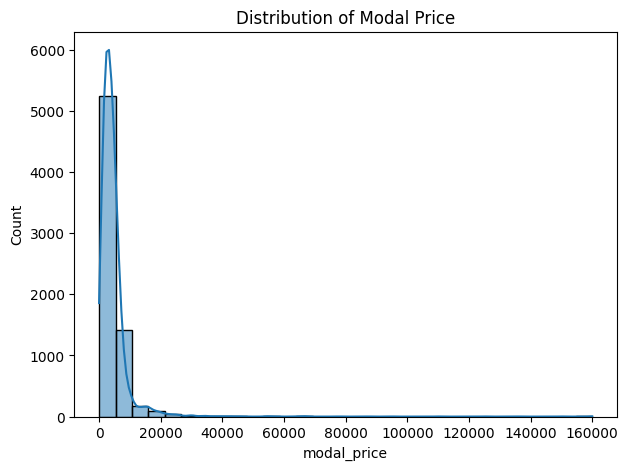

In [212]:

plt.figure(figsize=(7,5))
sns.histplot(df['modal_price'], bins=30, kde=True)
plt.title("Distribution of Modal Price")
plt.show()


INSIGHTS

The distribution is right-skewed-The long tail on the right side indicates that only a few commodities have very high prices, while most are affordable or medium-priced.
Most modal prices are concentrated in the lower price range-The highest bars appear on the left side of the chart, showing that most commodities are traded at relatively lower prices.
High-priced commodities are rare-The small bars at the extreme right show that premium or specialty commodities occur less frequently in the dataset.
Modal price has a clear central range-The peak of the histogram represents the most common market price range, which can be treated as the typical selling price in markets.
The KDE curve shows smooth price variation instead of sharp spikes-This indicates that prices change gradually across markets and commodities, rather than being clustered at only one fixed price.


## 3.3.2   Price trend over time-Line chart

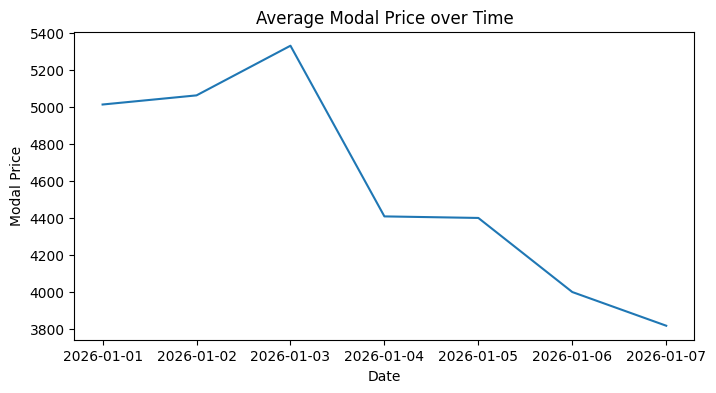

In [213]:
df['arrival_date'] = pd.to_datetime(df['arrival_date'])

date_price = df.groupby('arrival_date')['modal_price'].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(date_price['arrival_date'], date_price['modal_price'])
plt.title("Average Modal Price over Time")
plt.xlabel("Date")
plt.ylabel("Modal Price")
plt.show()

INSIGHTS

Prices change over time, not constant.The line shows that the average modal price varies from day to day, which means market prices are dynamic.
Short-term ups and downs indicate market fluctuations,Small rises and drops in the line suggest regular market movement due to supply, arrivals, and demand.
 Sudden peaks indicate temporary price increases.Any sharp upward point in the graph represents short-term price hikes, which may happen because of low supply or high demand on that date.Sudden drops show possible oversupply days,Sharp downward movements indicate more arrivals or reduced demand, leading to lower average prices.
This trend is useful for timing decisions.By observing this pattern, traders and buyers can identify better days to sell (higher price days) or buy (lower price days).

## 3.3.3 Region and Commodity Type vs Price-Grouped bar chart 

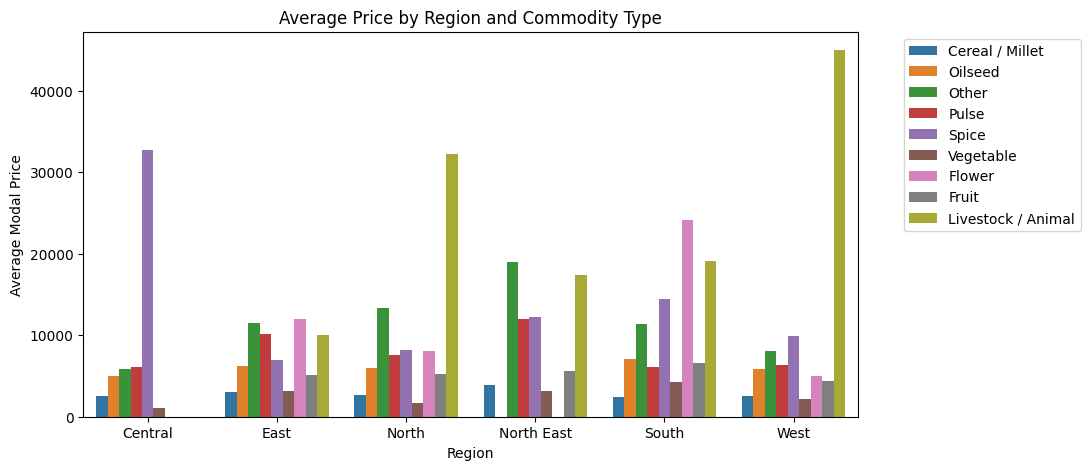

In [214]:
region_group_price = (
    df.groupby(['region','commodity_type'])['modal_price']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=region_group_price,
            x='region',
            y='modal_price',
            hue='commodity_type')
plt.title("Average Price by Region and Commodity Type")
plt.xlabel("Region")
plt.ylabel("Average Modal Price")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

INSIGHTS

Price levels vary significantly across regions for the same commodity group.

The South ,North and West regions show higher prices for Livestock / Animal and flower categories.

Regional differences suggest that local demand, availability and market structure influence prices.

## 3.3.4    Share of Commodity Type -Pie chart

In [215]:
import plotly.express as px

# Prepare data
counts = df['commodity_type'].value_counts().reset_index()
counts.columns = ['commodity_type', 'count']

# Interactive pie chart
fig = px.pie(
    counts,
    names='commodity_type',
    values='count',
    title=" Share of Records by Commodity Type",
    hole=0.3   # optional → makes it a donut chart
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.show()

INSIGHTS

The dataset is highly dominated by the Vegetable category, contributing nearly 68% of total records.
Fruit is the second largest group (about 13%), while other commodity types such as cereals, pulses, spices and oilseeds together form a much smaller share.
This indicates that the dataset is strongly skewed towards vegetables, which should be considered while drawing price-related conclusions.Staple commodities form the largest share.Specialty commodities have smaller but valuable presence.Distribution highlights market demand patterns.Helps prioritize commodity groups for analysis.

## 3.3.5  Average Modal Price by Grade across Commodity Types-Point plot

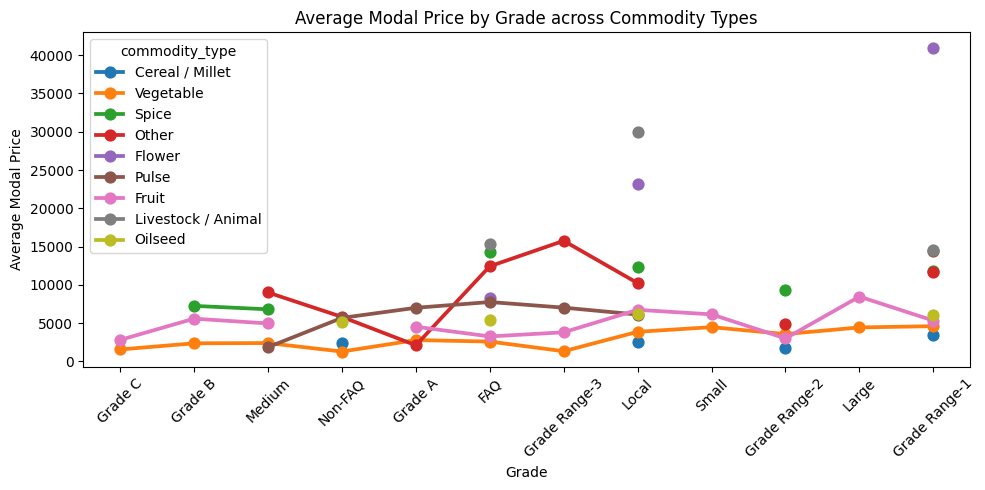

In [216]:

plt.figure(figsize=(10,5))

# order grades by average price (helps interpretation)
grade_order = (
    df.groupby('grade')['modal_price']
      .mean()
      .sort_values()
      .index
)

sns.pointplot(
    data=df,
    x='grade',
    y='modal_price',
    hue='commodity_type',
    order=grade_order,
    errorbar=None
)

plt.title("Average Modal Price by Grade across Commodity Types")
plt.xlabel("Grade")
plt.ylabel("Average Modal Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

INSIGHTS

Flower and Livestock / Animal commodity types consistently appear at the top of the price scale. This shows that perishable and specialty products command premium prices in the market.
Cereal / Millet and Vegetable remain low-priced across all even when the grade improves, these two commodity types do not show a sharp price increase, indicating they behave as staple commodities with relatively stable and affordable prices.
The same grade (for example FAQ or Local) produces very different prices for different commodity types. This means grade alone does not determine price —the commodity type and market value of the product are more influential.
Local and FAQ grades often record higher prices for high-value commodities. This indicates that in real markets, locally traded or commonly accepted quality grades still attract strong demand and good prices, especially for premium commodities.

Large price gaps between grades indicate strong quality-based market differentiation, For commodity types where the distance between grade lines is large, buyers are clearly willing to pay a premium for better grades, which is important for farmer and trader decision-making on grading and sorting.


## 3.3.6  Correlation Between Price Variables-Correlation Heatmap

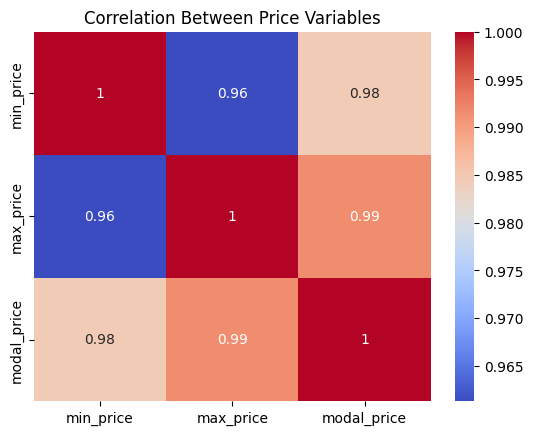

In [217]:
sns.heatmap(df[['min_price','max_price','modal_price']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Between Price Variables")
plt.show()


INSIGHTS

This visual shows relationships among price variables.
Modal and max prices move together.
min_price, max_price, and modal_price show a very strong positive correlation with each other.
This confirms that all three price measures move together and represent the same market trend.
Modal price is a good representative price.   No contradictory price behaviour observed.




## 3.3.7  Top 10 States by Average Model Price-Bar plot

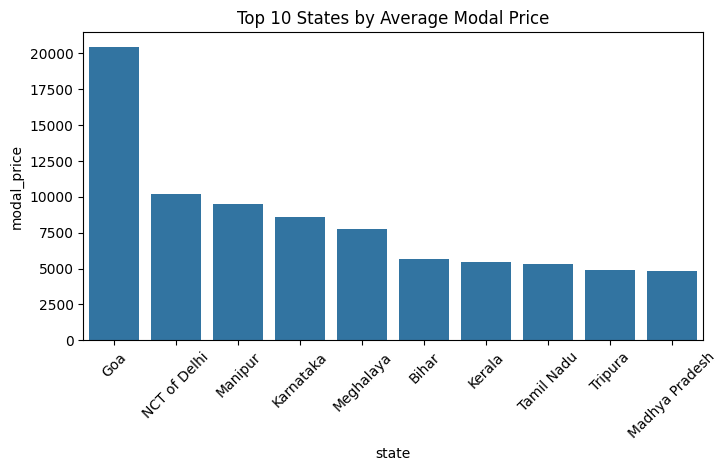

In [218]:
state_price = df.groupby('state')['modal_price'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=state_price, x='state', y='modal_price')
plt.title("Top 10 States by Average Modal Price")
plt.xticks(rotation=45)
plt.show()

INSIGHTS 

Goa stands far above all other states in the chart.This indicates that the commodities traded in Goa (mainly high-value and specialty items) are priced much higher on average compared to the rest of the states.After Goa, NCT of Delhi and Manipur show the next highest average modal prices.States such as Karnataka and Meghalaya fall in the middle range of the chart.This shows that these states have balanced market behaviour, neither extremely high nor very low in average prices.Large agricultural states show comparatively lower average prices.States like Kerala, Tamil Nadu and Madhya Pradesh appear in the lower half of the top-10 list.This indicates that markets with stronger production and supply tend to have more competitive and stable prices.There is a strong price gap between the top state and the rest.This highlights a clear regional price imbalance in Indian markets and confirms that average prices are highly influenced by local market structure, commodity mix and demand conditions, not only by geography.

The state-wise comparison shows that high-value and demand-driven markets (such as Goa and Delhi) record significantly higher average modal prices, while large production-oriented states maintain relatively lower and more stable price levels.

## 3.3.8   Price Distribution by Commodity Type -Box plot

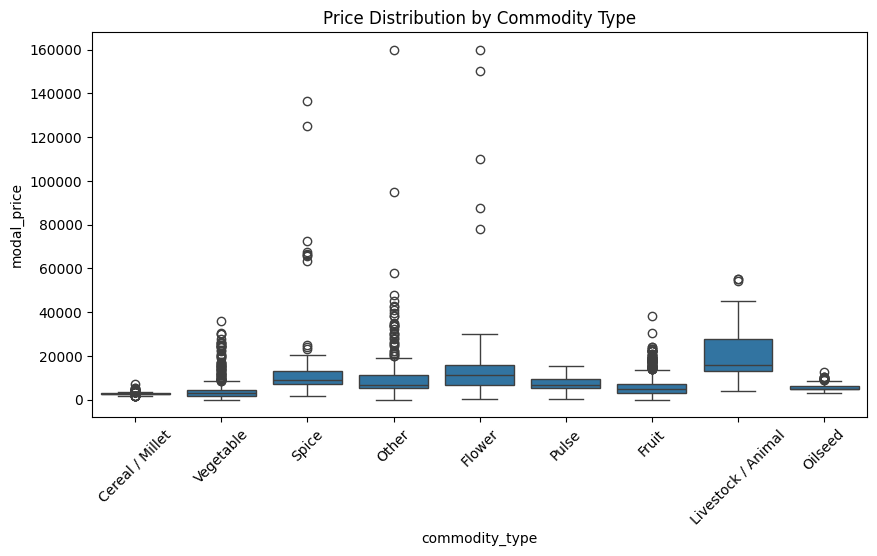

In [219]:
#----remove lower outliers using pandas before plotting----#
Q1 = df.groupby('commodity_type')['modal_price'].transform(lambda x: x.quantile(0.25))
Q3 = df.groupby('commodity_type')['modal_price'].transform(lambda x: x.quantile(0.75))

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

df_no_lower = df[df['modal_price'] >= lower_bound]

plt.figure(figsize=(10,5))
sns.boxplot(data=df_no_lower,
            x='commodity_type',
            y='modal_price')

plt.title("Price Distribution by Commodity Type")
plt.xticks(rotation=45)
plt.show()

Insight 

The box-plot shows clear differences in price levels and variability across commodity types.
Livestock/Animal, Flowers and Spices exhibit higher median prices and wider spread, indicating greater price variability.
Vegetables, Cereals/Millets and Fruits show lower median prices with relatively narrower ranges, suggesting more stable and lower-priced commodities.

## 3.3.9   Top 10 Market–State pairs with Highest Price Variation-Bar plot

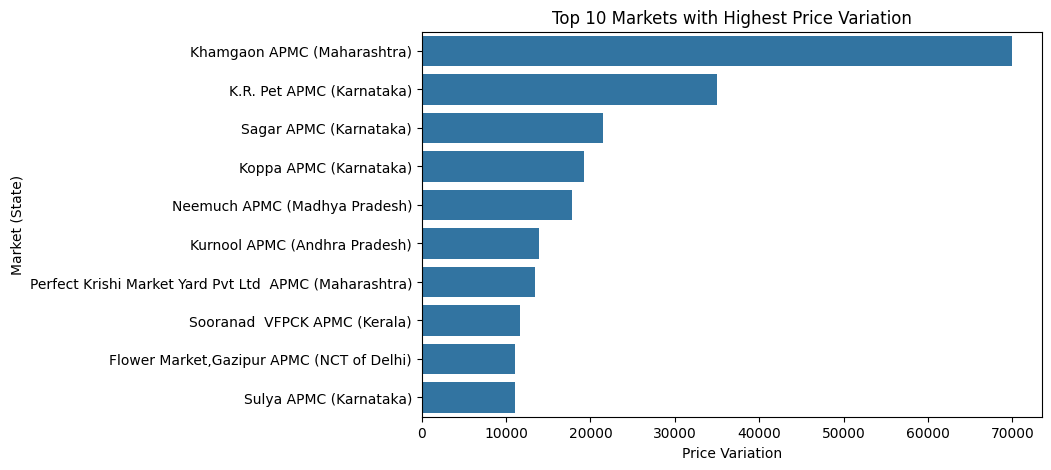

In [220]:
df['price_variation'] = df['max_price'] - df['min_price']
variation_table = df.groupby(['market','state'])['price_variation'].mean().reset_index()
top_variation = variation_table.sort_values(by='price_variation', ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_variation,
    x='price_variation',
    y=top_variation['market'] + " (" + top_variation['state'] + ")"
)

plt.title("Top 10 Markets with Highest Price Variation")
plt.xlabel("Price Variation")
plt.ylabel("Market (State)")
plt.show()

INSIGHTS


Khamgaon APMC in Maharashtra shows the highest price variation, indicating significant market volatility.
Multiple Karnataka markets also appear in the top 10, suggesting notable price fluctuations in that region.
Neemuch APMC (Madhya Pradesh) and Kurnool APMC (Andhra Pradesh) show moderate price variation.
This indicates comparatively more stable pricing than the top markets but still noticeable fluctuations.
Kerala market also appears in the top variation list.This suggests some commodities in Kerala markets also experience noticeable price variation, possibly due to transportation cost or seasonal availability. Presence of Delhi market Gazipur Flower Market (Delhi) appears in the list.
Flower markets often show high price volatility because flowers are highly perishable and demand changes daily.

## 3.3.10   Modal Price Spread by Grade-Strip plot

In [221]:
import plotly.express as px

fig = px.strip(
    df,
    x="grade",
    y="modal_price",
    color="grade",
    title="Modal Price Spread by Grade",
    hover_data=["commodity", "market", "state"]
)

fig.update_layout(
    xaxis_title="Grade",
    yaxis_title="Modal Price",
    showlegend=False
)

fig.show()

 INSIGHTS 
 
 Local grade shows the widest price spread.The Local grade has the largest vertical spread of points, ranging from very low prices to extremely high values (above 1,50,000).This shows that Local grade is highly inconsistent in price and depends strongly on the commodity and the market.FAQ grade contains several extreme high-price observations also shows multiple very high modal prices (above 1,20,000).
Although FAQ represents standard quality, some high-value commodities are traded under FAQ grade, leading to large price spikes.
 Non-FAQ and Grade B show comparatively tighter price ranges,most points are concentrated in a much smaller band.This indicates more stable and predictable prices for these grades compared to Local and FAQ.
Grade A has moderate prices with limited extreme values.The Grade A cluster mostly lies in the mid-price range and does not show very extreme high outliers.This suggests that Grade A trades are relatively controlled and less volatile.
 Grade Range categories show structured pricing behaviour.Grade Range-1, Grade Range-2 and Grade Range-3 form clearly separated price bands with fewer observations and smaller spread.These grades appear to follow more standardised pricing structures compared to Local and FAQ. Small and Large grades show limited participation and narrow spread
The Small and Large grades have fewer data points and a narrow price spread.This implies lower market activity and limited variability for size-based grading categories. High price variation is mainly driven by a small set of grades.Most extreme prices across the dataset are concentrated in only two grades: Local and FAQ These two grades are the main contributors to overall price volatility in the dataset.
Grade alone cannot fully explain price differences, Even within the same grade (especially Local and FAQ), prices vary drastically.
This clearly indicates that commodity type and market location play a major role in addition to grade.

## 3.3.11 Count by Grade and Commodity Type-Bubble Chart

In [222]:
# Prepare count data
count_df = (
    df.groupby(['grade', 'commodity_type'])
      .size()
      .reset_index(name='count')
)

fig = px.scatter(
    count_df,
    x="commodity_type",
    y="grade",
    size="count",
    color="commodity_type",
    size_max=60,
    title="Record Count by Grade and Commodity Type (Bubble Chart)",
)

fig.update_layout(
    xaxis_title="Commodity Type",
    yaxis_title="Grade"
)

fig.show()


INSIGHTS 

FAQ and Local grades dominate the dataset-The largest bubbles appear for FAQ and Local grades across most commodity types.This means most market records are reported under these two quality grades.
Some commodity types have very limited grade variety-A few commodity types show bubbles for only 1–2 grades.This indicates less grading diversity for those commodities in the markets.
Grading is not consistent across commodity types-You can see that certain grades (like Grade A / Grade B / Medium / Large) appear only in specific commodity types.
This means grade labels are commodity-dependent, not standardized for all items.
Market reporting is highly concentrated in few grade categories-Most of the total observations are clustered in a small number of grade–commodity combinations.
For analysis and modeling, rare grades may not be statistically reliable.
This helps identify reliable segments for decision making-Commodity types that have many records and multiple grade bubbles are more suitable for price trend analysis and forecasting than commodity types with very small bubbles.
 
 visualization clearly shows that most market data is concentrated in a few grades and varies strongly by commodity type, which is critical when selecting segments for price analysis and decisions.

## 3.3.12 Market Activity and Price Comparison of Top 10 Commodities

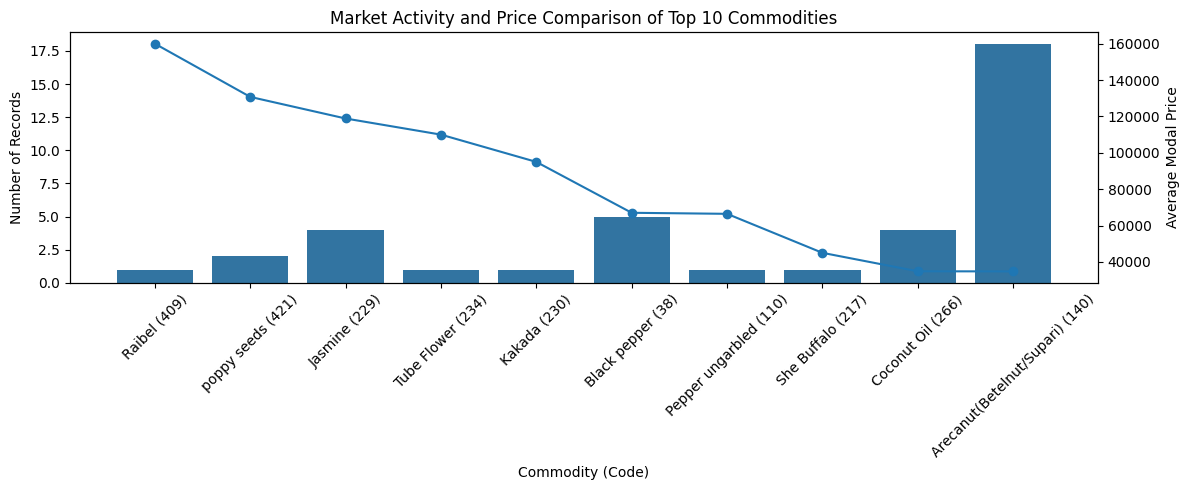

In [223]:

#  Average price per commodity + code
price_df = (
    df.groupby(['commodity_code','commodity'])['modal_price']
      .mean()
      .reset_index(name='avg_price')
)

#  Count per commodity + code
count_df = (
    df.groupby(['commodity_code','commodity'])
      .size()
      .reset_index(name='count')
)

#  Merge both
combo_df = pd.merge(price_df, count_df,
                     on=['commodity_code','commodity'])

#  Take top 10 by average price
combo_df = combo_df.sort_values(
    by='avg_price', ascending=False
).head(10)

#  Create label -> Commodity (Code)
combo_df['label'] = (
    combo_df['commodity'] + " (" +
    combo_df['commodity_code'].astype(str) + ")"
)

#  Plot
fig, ax1 = plt.subplots(figsize=(12,5))

# Bar plot → count
sns.barplot(
    data=combo_df,
    x='label',
    y='count',
    ax=ax1
)

ax1.set_ylabel("Number of Records")
ax1.set_xlabel("Commodity (Code)")
ax1.tick_params(axis='x', rotation=45)

# Second axis → average price (line)
ax2 = ax1.twinx()

ax2.plot(
    combo_df['label'],
    combo_df['avg_price'],
    marker='o'
)

ax2.set_ylabel("Average Modal Price")

plt.title("Market Activity and Price Comparison of Top 10 Commodities")
plt.tight_layout()
plt.show()


INSIGHTS

Arecanut/Betelnut (140) shows by far the highest number of records (count) among the top commodities.This means it is the most frequently traded / reported commodity in the selected group,,indicating strong and consistent market activity.High-price commodities appear with much lower trading frequency Commodities such as Rajbel (409),Poppy seeds (421),Jasmine (229),Tube flower (234) show very high average modal prices, but their record counts are low.
This shows that high-value and specialty commodities are traded less frequently, but at much higher prices.
Black pepper (38) shows a balanced demand–value profile,It has a moderate number of records, and a high average modal price compared to most other commodities.This indicates that black pepper is both a commercially important commodity, and a high-value product in the market.
Coconut oil (266) and Arecanut/Betelnut (140) show high market presence with relatively lower prices,their average modal prices are lower than premium commodities such as flowers and spices.This suggests they behave more like regularly traded consumption commodities, not niche premium products.
There is a clear inverse pattern between frequency and price.From the combined bar–line view:commodities with very high prices usually have low counts, and
commodities with high counts usually have moderate or lower prices.This highlights an important market pattern:high-value commodities are niche and volatile, whereas high-volume commodities are more stable and widely traded.


The combined analysis shows that frequently traded commodities such as Arecanut/Betelnut and Coconut oil form the stable backbone of the market, while high-priced commodities like flowers, poppy seeds and spices remain niche but premium segments.

## 3.3.13 Average Modal Price by District and Commodity Type-Heatmap

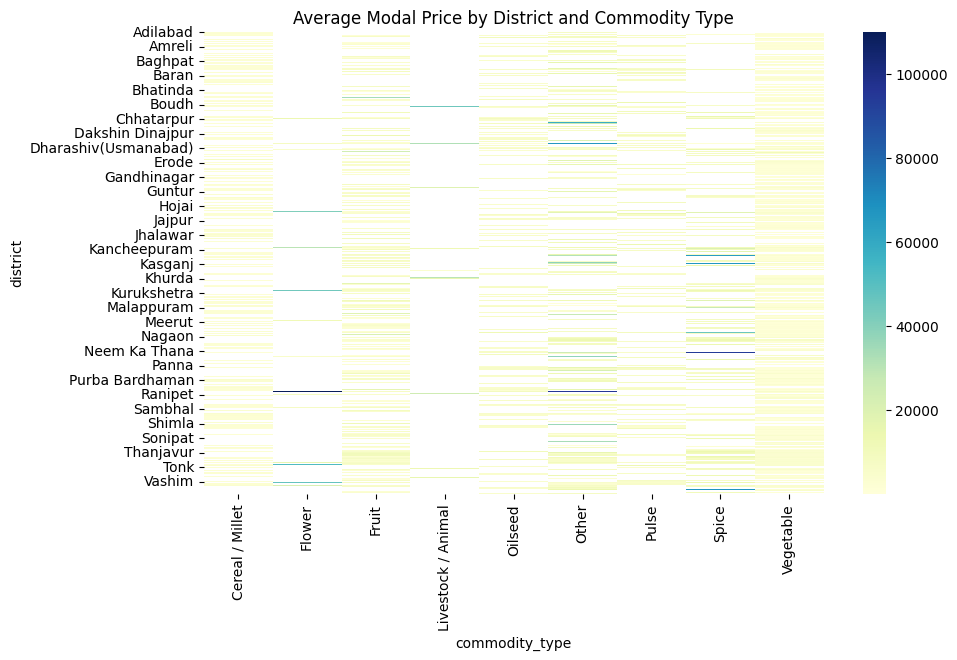

In [224]:
pivot_dist = pd.pivot_table(
    df,
    values='modal_price',
    index='district',
    columns='commodity_type',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_dist, cmap='YlGnBu')
plt.title("Average Modal Price by District and Commodity Type")
plt.show()


INSIGHTS 

“Spice” is the costliest commodity type in many districts. The Spice column clearly contains the darkest and most frequent high-value cells across districts.For example, very strong peaks are visible in districts such as
Neem Ka Thana and Kancheepuram.➡ This shows that spice commodities consistently command much higher average modal prices compared to most other commodity type. “Other” commodity group shows sharp price spikes in selected districts
The Other category has several isolated but very dark cells.Notable examples appear in districts likeDakshin Dinajpur and Ranipet.This indicates that the ‘Other’ category contains a few high-value or specialty commodities that strongly raise the district-level average price.
Flower prices are highly district-dependent .The Flower column shows large variation across districts.
For instance, Ranipet shows a visibly higher flower price compared to many other districts such as Baghpat or Amreli.This suggests that flower prices are strongly influenced by local market conditions and supply chains, rather than showing uniform pricing across regions.
 Livestock / Animal prices remain relatively low and stable aross almost all districts ( Malappuram,Meerut, and Shimla),
the Livestock / Animal column appears very light in colour.This indicates that average modal prices for livestock-related commodities are comparatively lower and more stable than spices, flowers or ‘other’ commodities.Vegetable prices are consistently low across most districts The Vegetable column is dominated by light shades for nearly all districts shown (such as Thanjavur,Sonipat, and Panna).
This confirms that vegetables form a low-price, high-volume segment, with limited extreme price behaviour compared to spices or specialty categories.


The district-wise heatmap clearly shows that price variation is driven mainly by high-value categories such as spices, flowers and selected ‘other’ commodities, while vegetables and livestock remain comparatively stable and low-priced across most districts.

## 3.3.14 Price Variables for Top 5 Commodity Types-Pair Plot

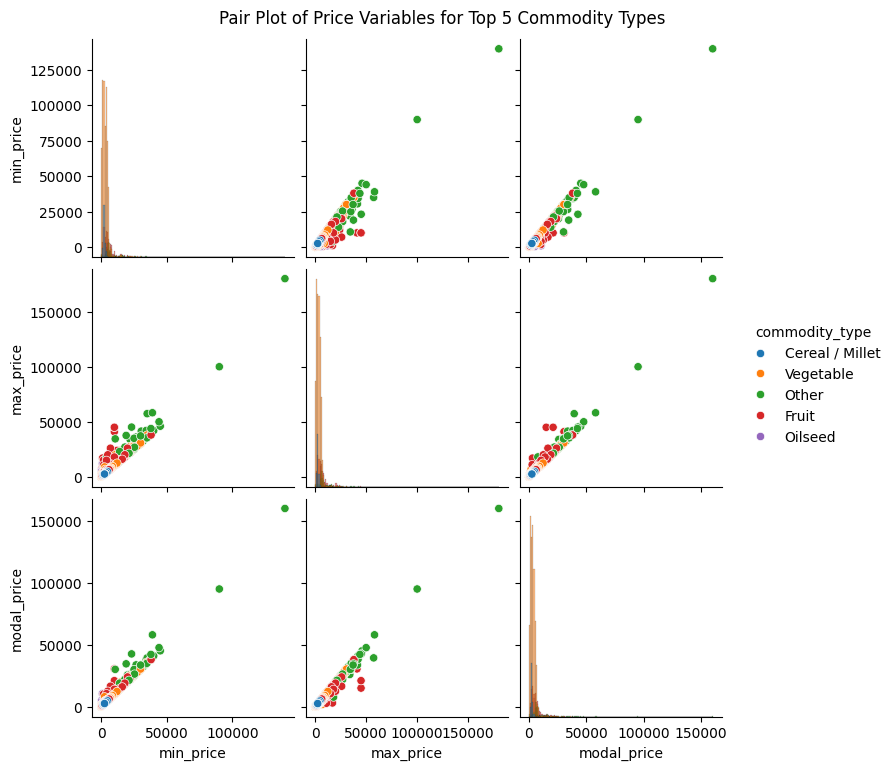

In [225]:
top5_types = df['commodity_type'].value_counts().head(5).index
top5_types
top5_df = df[df['commodity_type'].isin(top5_types)]
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    top5_df,
    vars=['min_price', 'max_price', 'modal_price'],
    hue='commodity_type',
    diag_kind='hist'
)
plt.suptitle("Pair Plot of Price Variables for Top 5 Commodity Types", y=1.02)
plt.show()



INSIGHTS

Modal price closely follows both minimum and maximum prices,This indicates that the reported modal price is consistent and reliable across most commodity types.Strong positive relationship between Min–Max and Modal prices.When the minimum price increases, both the maximum and modal prices also increase in most cases.Some commodity types show wider price spread,The larger scatter between min_price and max_price for certain commodity types indicates higher market volatility.Overlapping clusters across commodity types. Different commodity types sometimes operate in similar price ranges, meaning price alone cannot clearly separate all types.
A few scattered points indicate unusual or extreme prices,These may represent special markets,quality/grade differences or sudden price fluctuations and should be reviewed for decision making.Overall, this visualization helps understand price behaviour consistency and volatility across major commodity types.

## 3.3.15 Top 5 Commodities (with Code) in Each Commodity Type-Facet Bar Charts 

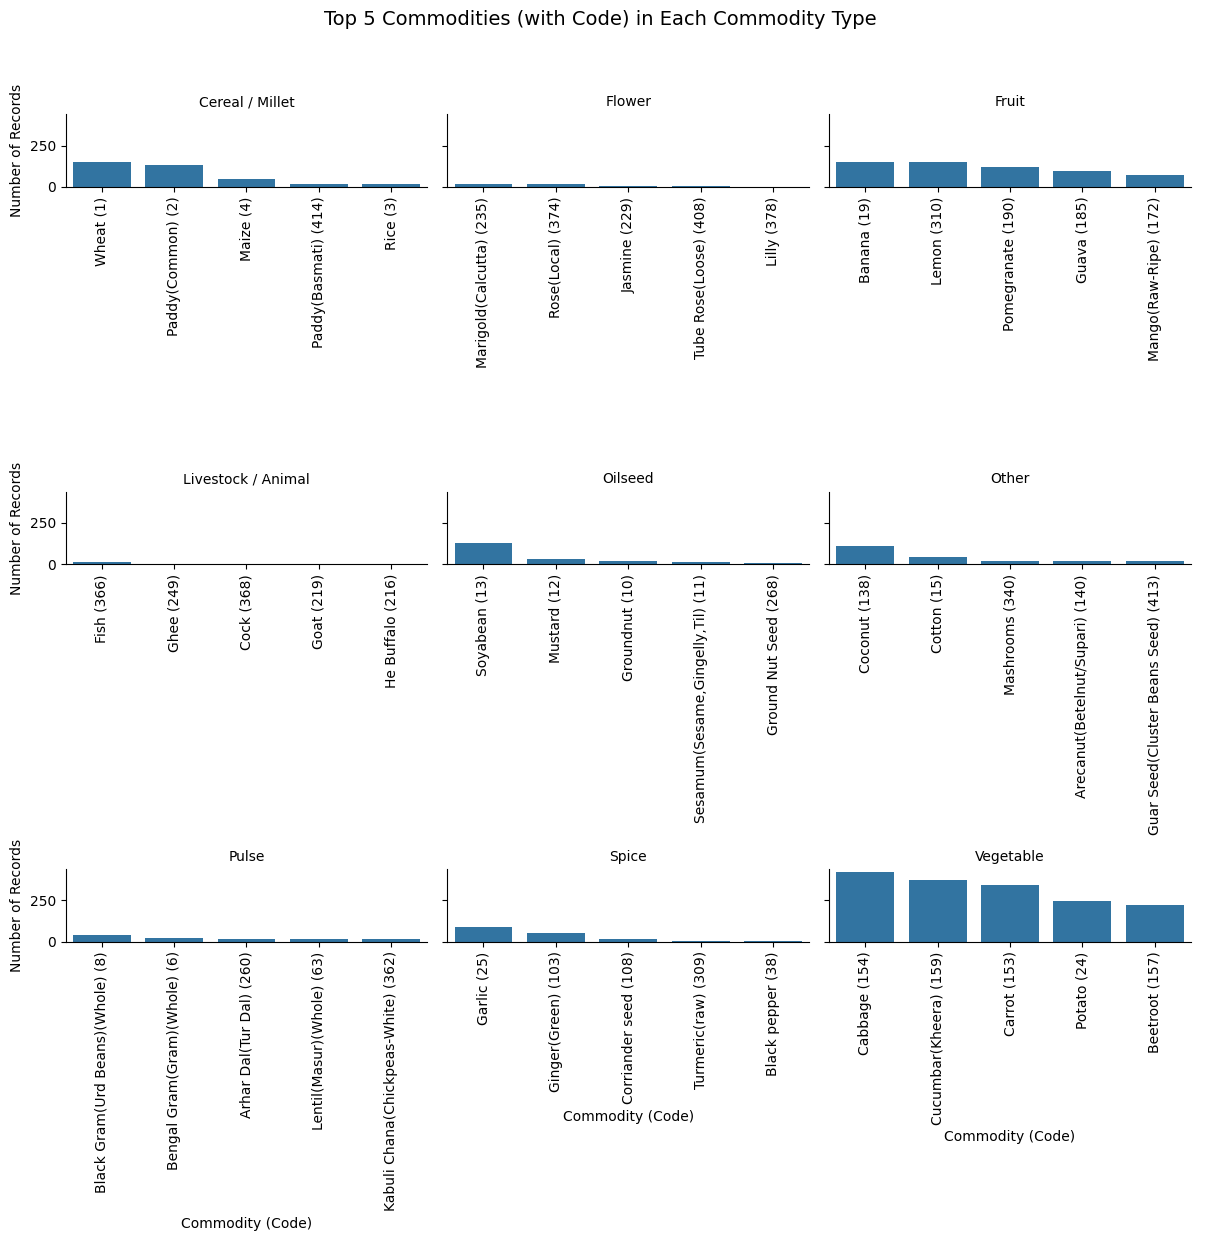

In [226]:

# -----------------------------
# 1. Count records per commodity inside each commodity type
# -----------------------------
count_df = (
    df
    .groupby(["commodity_type", "commodity", "commodity_code"])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# 2. Take TOP 5 commodities in each commodity type
# -----------------------------
top5_each_type = (
    count_df
    .sort_values(["commodity_type", "count"], ascending=[True, False])
    .groupby("commodity_type")
    .head(5)
)

# -----------------------------
# 3. Create label : Commodity (Code)
# -----------------------------
top5_each_type["commodity_label"] = (
    top5_each_type["commodity"] + " (" +
    top5_each_type["commodity_code"].astype(str) + ")"
)

# -----------------------------
# 4. Facet bar chart
# -----------------------------
g = sns.catplot(
    data=top5_each_type,
    x="commodity_label",
    y="count",
    col="commodity_type",
    kind="bar",
    col_wrap=3,
    height=4,
    sharex=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Commodity (Code)", "Number of Records")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=90)
g.fig.suptitle(
    "Top 5 Commodities (with Code) in Each Commodity Type",
    fontsize=14,
    y=1.03
)
plt.tight_layout()
plt.show()


INSIGHTS 

Cereal / Millet category is dominated by Wheat.In the Cereal / Millet panel, Wheat (1) has the highest number of records by a wide margin.
It is followed by Paddy/Commom (2) and Maize (4), while Paddy (Basmati) (414) and Rice (3) appear much less frequently.This clearly shows that wheat and common paddy are the main traded cereals, whereas basmati and rice are more niche in this dataset. Vegetables are the most frequently recorded commodities overall.In the Vegetable panel, all five commodities show very high counts:Cabbage (154
),Cucumb/Kheera (159),Carrot (153),Potato (24),Beetroot (157).
Compared to all other commodity types in the chart, vegetables have the highest and most balanced trading frequency, indicating high daily market activity and continuous demand. Fruits and Flowers show moderate but consistent trading In the Fruit panel:Banana (19), and Lemon (310) have the highest counts,
followed by Pomegranate (109), Guava (135) and Mango (Raw/Ripe) (127).In the Flower panel:Marigold/Calcutta (253) and Rose(Local) (374) dominate,while Jasmine (229) and Tube Rose(Local) (408) appear slightly less.This indicates that fruits and flowers are regularly traded, but their market activity is lower than vegetables and cereals.Oilseed category is highly concentrated in Soyabean.In the Oilseed panel, Soyabean (13) clearly stands out as the most recorded commodity.All others such as Mustard (12), Groundnut (10), Sesamum/Sesame (11) and Ground Nut Seed (268) have much smaller counts.
This shows that soyabean is the dominant oilseed commodity in market reporting, making it a key driver for oilseed price analysis.
 Livestock / Animal and Pulse categories have very limited market coverage,In the Livestock / Animal panel Fish (66), Goat (49), Cock (38), Goat (119) and He Buffalo (216) show very low counts.Similarly, in the Pulse panel:Black Gram (Urad) (8),Bengal Gram (6),Arhar/Tur Dal (20),Lentil/Masur (63),Kabuli Chana (362).all appear with relatively small frequencies.This suggests that livestock and pulse commodities are under-represented in the dataset, and their market activity is captured far less compared to vegetables, cereals and fruits.

The visualization clearly shows that vegetables and cereals dominate market activity, oilseed trading is strongly driven by soyabean, fruits,spices other
 form a moderate-volume segment, while livestock,flowers and pulses appear as low-coverage
 categories in the dataset.

<div style="background-color:#e3f2fd; padding:15px; border-radius:10px;">
  <h1 style="color:#0d47a1; text-align:center;">
    <strong>4. Insight Generation and Report</strong>
  </h1>
</div>

### 4.1 **Key Insights from Visual Analysis**


##### Insight 1 – Grade has a strong influence on price

Across all visualisations, higher quality grades such as FAQ and grade-range categories consistently achieve higher modal prices than Local and Non-FAQ grades.
This confirms that grading directly affects price realisation in Indian markets.


##### Insight 2 – Flowers Livestock and spices form the high-value segment

In grade-wise and commodity-wise price charts, flowers and spices repeatedly appear at the top of the price scale.
They behave as premium commodities with high average modal prices.


##### Insight 3 – Vegetables and cereals are low-price but high-volume commodities

Count-based charts and distribution plots clearly show that vegetables and cereals appear most frequently in the dataset.
However, their prices remain relatively lower compared to other commodity categories.

This indicates volume-driven markets with relatively smaller margins.


##### Insight 4 – Significant interstate and inter-market price variation exists

The state-level and market-level average price charts show large differences in modal prices between states and markets.
Some states and markets consistently show much higher prices than others.

This reflects strong regional market behaviour and demand–supply differences.


##### Insight 5 – Certain markets show very high price volatility

From the market-wise variation analysis, a small number of markets show exceptionally large price fluctuations.
These markets act as high-risk trading zones.


##### Insight 6 – District-wise heatmap highlights premium commodity influence

The district versus commodity-type heatmap shows that most high-price concentration is driven by:

flower commodities,spice commodities, and selected speciality items.Vegetables remain comparatively stable across districts.


##### Insight 7 – Wheat and paddy dominate cereal trading

In the “Top 5 commodities in each commodity type” visualisation, wheat and common paddy dominate the cereal and millet group by record count.
They form the core of cereal-based market activity.


##### Insight 8 – Soyabean dominates the oilseed segment

Oilseed analysis clearly shows soyabean contributing the highest number of market records.
This implies that overall oilseed price trends are largely influenced by soyabean.


##### Insight 9 – Livestock and pulse commodities have limited representation

The livestock and pulse categories appear with very small counts compared to vegetables, cereals and fruits.
This limits the reliability of conclusions for these two categories.


##### Insight 10 – High price does not mean high market participation

The combined count versus price visualisation shows that many high-priced commodities have very low market activity, while frequently traded commodities usually have lower prices.
This demonstrates a clear separation between high-value and high-volume commodities.


##### Insight 11 – Modal price distribution is right-skewed

The histogram of modal prices shows that most records lie in the lower price range, with a small number of very high-priced observations forming a long tail.

This indicates that a small set of premium commodities strongly influences the overall price range.


##### Insight 12 – Short-term price movements are volatile

The average modal price over time plot shows frequent rises and falls rather than a stable trend.
Short-term arrivals and market conditions strongly affect daily prices.


### 4.2 **Overall Conclusion**

The analysis reveals a clear structural separation in Indian agricultural markets:

High-volume and relatively low-price commodities
such as vegetables and cereals dominate market activity.

Low-volume but high-price commodities
such as flowers and spices form a premium segment.

Commodity grade plays a crucial role in price formation.
Regional and market-level differences significantly influence price behaviour, and a small number of markets exhibit high volatility.

The study demonstrates that descriptive and interactive visual analytics can effectively support market intelligence and operational decisions.

### 4.3 **Limitations and Demerits of the Dataset**

Arrival quantity or traded volume is not available, limiting demand–supply analysis.

Livestock and pulse categories have very limited data coverage.

The time span is short, which restricts long-term trend and seasonality analysis.

External influencing factors such as weather, transport cost and production volume are not included.

Grade definitions are categorical and lack standard quality measurements.

### 4.4  **Future Recommendations Based on Findings**

1. Include arrival quantity and volume for demand–supply analysis.

2. Add multi-year data to enable seasonal and trend modelling.

3. Standardise commodity grade categories.

4. Integrate market arrival and stock information.

5. Build forecasting models for major commodities and markets.

### 4.5 **Final Remark**

This project demonstrates how structured visual analytics and interactive dashboards can transform agricultural market data into actionable insights.
With the integration of quantity data, forecasting models and broader market coverage, the system can evolve into a practical decision-support tool for farmers, traders and policy planners.